In [1]:
import pandas as pd

from derivative_pricing.models.market import MarketData
from derivative_pricing.models.options import EuropeanOption, OptionType
from derivative_pricing.utils.monte_carlo_utils import (
    estimate_convergence_rates,
    estimate_required_simulations,
    find_observed_required_simulations,
    plot_confidence_interval_coverage,
    plot_error_convergence,
    plot_price_convergence,
    plot_variance_convergence,
    run_variance_experiment,
    summarise_variance_experiment,
)

market = MarketData(
    spot=100.0,
    risk_free_rate=0.05,
    volatility=0.20,
)

scenarios = {
    "ITM": EuropeanOption(
        strike=80.0,
        maturity=1.0,
        type=OptionType.CALL,
    ),
    "ATM": EuropeanOption(
        strike=100.0,
        maturity=1.0,
        type=OptionType.CALL,
    ),
    "OTM": EuropeanOption(
        strike=120.0,
        maturity=1.0,
        type=OptionType.CALL,
    ),
}

simulation_counts = [
    100,
    300,
    1_000,
    3_000,
    10_000,
    30_000,
    100_000,
    300_000,
    1_000_000,
]

In [ ]:
frames = []

for scenario, option in scenarios.items():
    frames.append(
        run_variance_experiment(
            scenario=scenario,
            option=option,
            market=market,
            simulation_counts=simulation_counts,
            repetitions=50,
            confidence_level=0.95,
            base_seed=42,
        )
    )

results = pd.concat(
    frames,
    ignore_index=True,
)

summary = summarise_variance_experiment(
    results
)

convergence_rates = estimate_convergence_rates(
    summary
)

In [3]:
summary[
    [
        "scenario",
        "simulations",
        "black_scholes_price",
        "mean_monte_carlo_price",
        "empirical_variance",
        "mean_standard_error",
        "mean_ci_half_width",
        "rmse",
        "confidence_interval_coverage",
    ]
]

,scenario,simulations,black_scholes_price,mean_monte_carlo_price,empirical_variance,mean_standard_error,mean_ci_half_width,rmse,confidence_interval_coverage
0,ATM,100,10.450584,10.605890,2.468593,1.449757,2.841471,1.563119,0.92
1,ATM,300,10.450584,10.500153,0.663748,0.847427,1.660927,0.808041,0.96
2,ATM,1000,10.450584,10.425859,0.216115,0.465728,0.912811,0.460873,0.96
3,ATM,3000,10.450584,10.448770,0.078293,0.268714,0.526670,0.277002,0.96
4,ATM,10000,10.450584,10.465459,0.020331,0.147331,0.288763,0.141935,0.96
5,ATM,30000,10.450584,10.452704,0.005854,0.085104,0.166801,0.075774,0.92
6,ATM,100000,10.450584,10.437666,0.001234,0.046502,0.091143,0.037094,0.98
7,ATM,300000,10.450584,10.455855,0.000549,0.026892,0.052708,0.023780,0.98
8,ATM,1000000,10.450584,10.452494,0.000221,0.014721,0.028852,0.014829,0.98
9,ITM,100,24.588835,24.983624,3.713005,1.884240,3.693042,1.947974,0.96


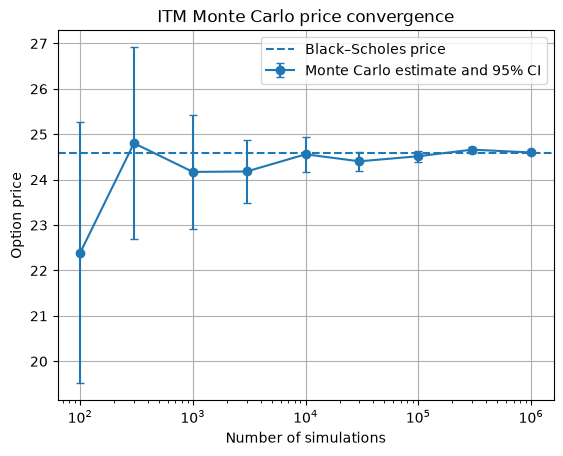

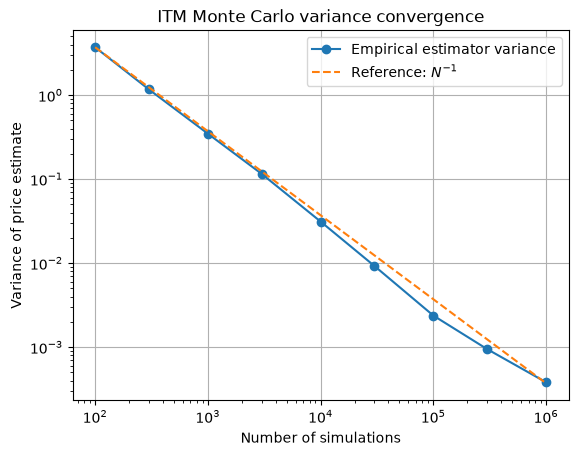

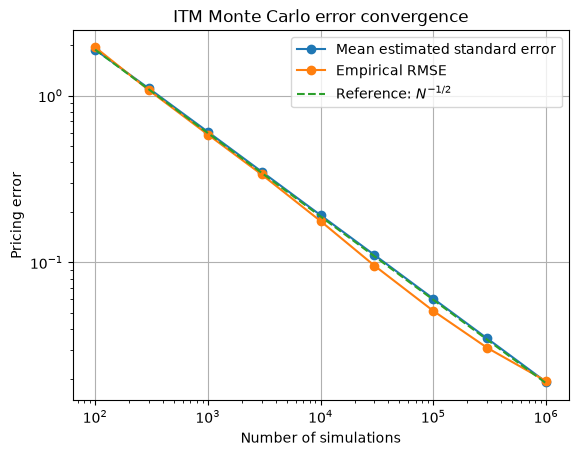

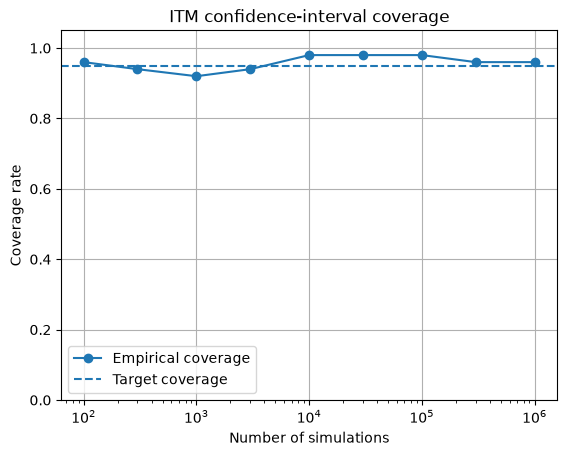

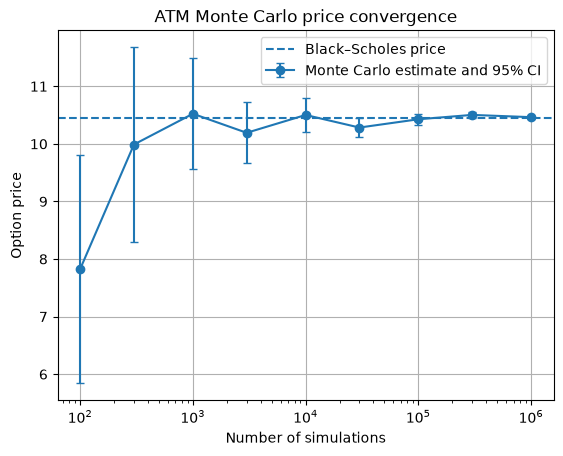

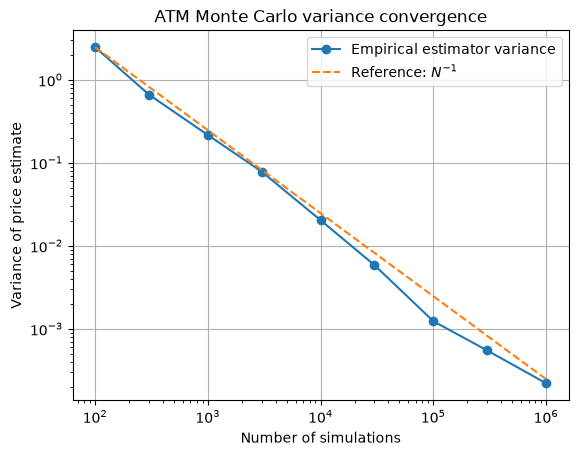

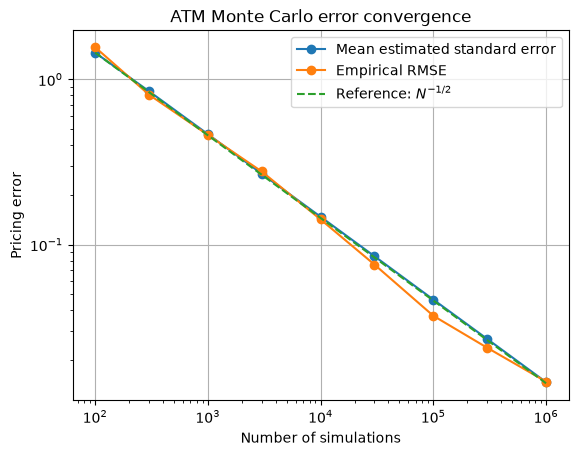

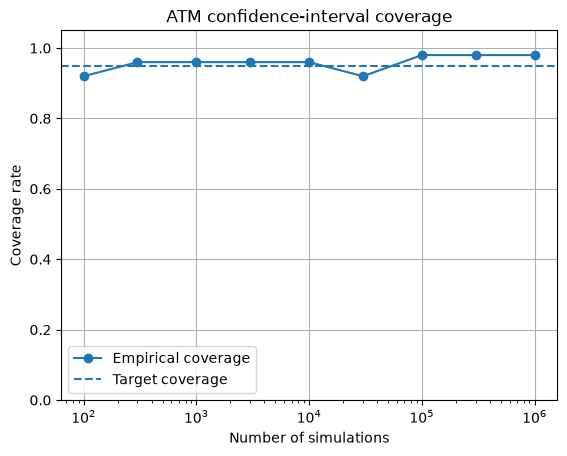

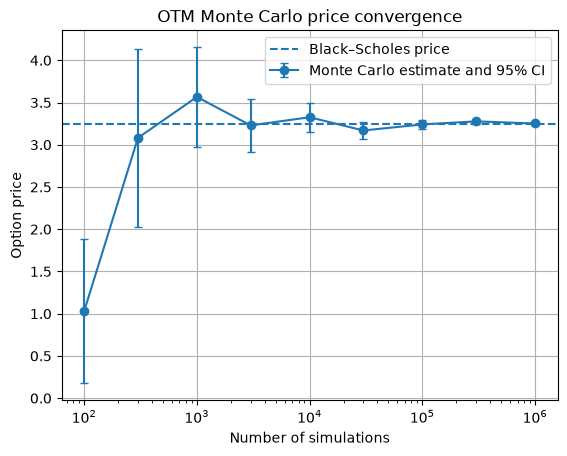

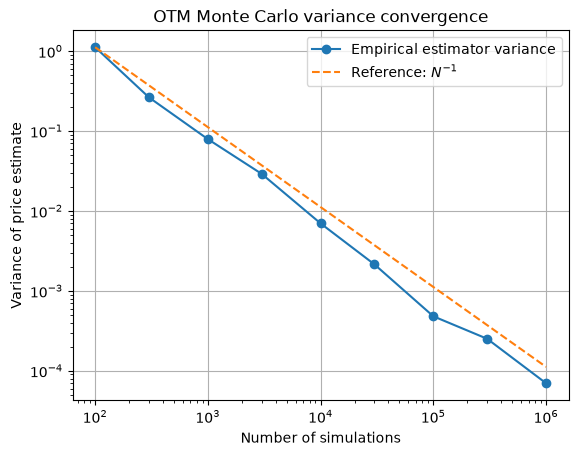

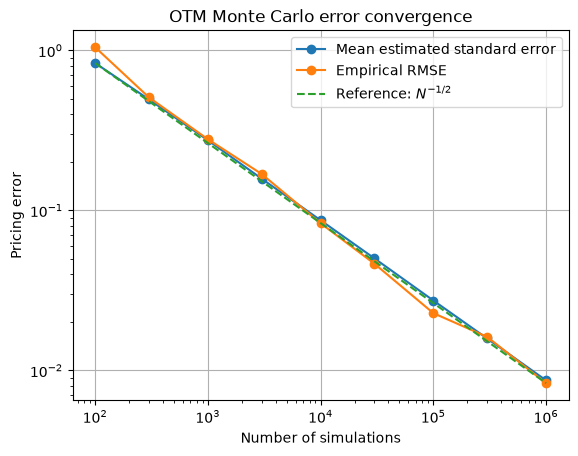

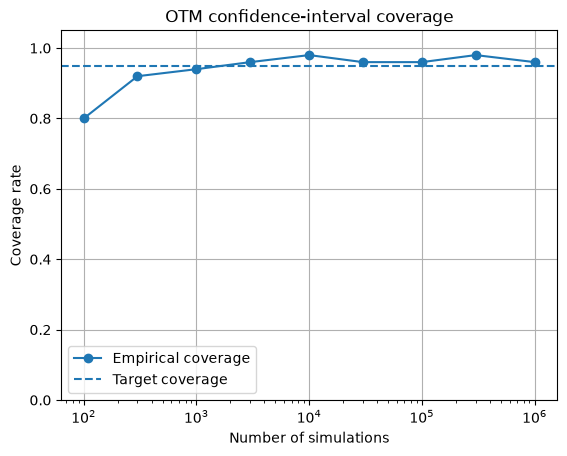

In [4]:
for scenario in scenarios:
    plot_price_convergence(
        results,
        scenario=scenario,
    )

    plot_variance_convergence(
        summary,
        scenario=scenario,
    )

    plot_error_convergence(
        summary,
        scenario=scenario,
    )

    plot_confidence_interval_coverage(
        summary,
        scenario=scenario,
    )

In [5]:
target_half_width = 0.01

pilot_estimates = []

for scenario, option in scenarios.items():
    estimate = estimate_required_simulations(
        option=option,
        market=market,
        target_half_width=target_half_width,
        confidence_level=0.95,
        pilot_simulations=10_000,
        seed=42,
    )

    estimate["scenario"] = scenario
    pilot_estimates.append(estimate)

pilot_estimates_df = pd.DataFrame(
    pilot_estimates
)

pilot_estimates_df

,pilot_simulations,pilot_price,estimated_discounted_payoff_sd,confidence_level,target_half_width,required_simulations,scenario
0,10000,24.448483,19.207372,0.95,0.01,14172031,ITM
1,10000,10.345182,14.766266,0.95,0.01,8376017,ATM
2,10000,3.238218,8.757690,0.95,0.01,2946289,OTM


In [6]:
observed_requirements = (
    find_observed_required_simulations(
        summary=summary,
        target_half_width=target_half_width,
        minimum_coverage=0.90,
    )
)

observed_requirements

,scenario,target_half_width,required_simulations,achieved_half_width,coverage
0,ATM,0.01,None,None,None
1,ITM,0.01,None,None,None
2,OTM,0.01,None,None,None
